<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/main/AlexaDandridgeHomework5_NeuralNetworkswithKeras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Building and Experimenting with Neural Networks

### Importing Items

In [7]:
!pip install category_encoders

In [8]:
pip install sweetviz

Libraries, Importing Data, EDA

In [9]:
# importing libraries
import numpy as np
import pandas as pd
from scipy.stats import boxcox
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import sweetviz as sv
from sklearn.cluster import KMeans
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [10]:
from google.colab import files
uploaded = files.upload()

adult = pd.read_csv("adult.csv")
adult.head()

Saving adult.csv to adult (1).csv


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [11]:
# replace ? with np.nan
adult = adult.replace("?", np.nan)
adult.head()

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# convert gender to 0/1 (doesn't need categorical encoding since it's binary)
if "gender" in adult.columns:
    adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [12]:
# fixed train/test split for the entire notebook

train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


In [13]:
# one hot encoding low cardinality features for models that don't handle categorical variables natively

adult_ohe = adult.copy()

adult_ohe = pd.get_dummies(
    adult_ohe,
    columns=["marital-status", "relationship", "race", "workclass"],
    drop_first=True
)

# quick target encoding for screening only (this has data leakage--screening only, not for final model)
occupation_encoder = ce.TargetEncoder(cols=["occupation"])
adult_ohe["occupation_encoded"] = occupation_encoder.fit_transform(
    adult_ohe[["occupation"]], adult_ohe["income"]
)["occupation"]

native_country_encoder = ce.TargetEncoder(cols=["native-country"])
adult_ohe["native_country_encoded"] = native_country_encoder.fit_transform(
    adult_ohe[["native-country"]], adult_ohe["income"]
)["native-country"]

adult_ohe.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,race_White,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded
0,25,226802,11th,7,Machine-op-inspct,1,0,0,40,United-States,...,False,False,False,True,False,False,False,False,0.123097,0.243977
1,38,89814,HS-grad,9,Farming-fishing,1,0,0,50,United-States,...,True,False,False,True,False,False,False,False,0.116107,0.243977
2,28,336951,Assoc-acdm,12,Protective-serv,1,0,0,40,United-States,...,True,True,False,False,False,False,False,False,0.313327,0.243977
3,44,160323,Some-college,10,Machine-op-inspct,1,7688,0,40,United-States,...,False,False,False,True,False,False,False,False,0.123097,0.243977
4,18,103497,Some-college,10,NaN,0,0,0,30,United-States,...,True,False,False,False,False,False,False,False,0.094340,0.243977


In [14]:
# OPTIONAL standalone example using feature-engine

# if needed:
!pip install feature-engine

from feature_engine.transformation import YeoJohnsonTransformer
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder

df_fe = adult.copy()

cat_cols = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = ["capital-gain", "capital-loss"]

# make missing categorical values explicit
df_fe[cat_cols] = df_fe[cat_cols].fillna("Unknown")

# transform skewed numeric features
yj = YeoJohnsonTransformer(variables=num_cols)
df_fe = yj.fit_transform(df_fe)

# group rare categories
rare = RareLabelEncoder(tol=0.01, variables=cat_cols)
df_fe = rare.fit_transform(df_fe)

# frequency encode categorical variables
freq = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
df_fe = freq.fit_transform(df_fe)

print("Example after feature-engine transformations + encoding:")
print(df_fe[num_cols + cat_cols[:3]].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 8.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable marital-status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable relationship is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable race is less than that indicated in n_categories. Thus, all categ

Example after feature-engine transformations + encoding:
   capital-gain  capital-loss  workclass  education  marital-status
0      0.000000           0.0   0.694198   0.037099        0.329982
1      0.000000           0.0   0.694198   0.323164        0.458192
2      0.000000           0.0   0.064207   0.032779        0.458192
3      0.728649           0.0   0.694198   0.222718        0.458192
4      0.000000           0.0   0.057307   0.222718        0.329982


In [15]:
# Create clean copy for neural network
adult_nn = adult.copy()

# Fill missing categorical values
cat_cols = adult_nn.select_dtypes(include=["object", "category"]).columns.tolist()
adult_nn[cat_cols] = adult_nn[cat_cols].fillna("Unknown")

# Separate X and y
X = adult_nn.drop("income", axis=1)
y = adult_nn["income"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Use fixed train/test split indices
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print(X_train.shape)
print(X_test.shape)

(39073, 100)
(9769, 100)


In [16]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(39073, 100)
(9769, 100)


Building a baseline NN

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [18]:
# constructing the baseline neural network

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train_scaled.shape[1],))

x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="adult_income_model")

model.summary()

Model: "adult_income_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# compiling the model
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8226 - loss: 0.3799 - val_accuracy: 0.8372 - val_loss: 0.3404
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8454 - loss: 0.3267 - val_accuracy: 0.8433 - val_loss: 0.3317
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8509 - loss: 0.3163 - val_accuracy: 0.8477 - val_loss: 0.3272
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8544 - loss: 0.3102 - val_accuracy: 0.8482 - val_loss: 0.3257
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8562 - loss: 0.3061 - val_accuracy: 0.8480 - val_loss: 0.3246
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8579 - loss: 0.3031 - val_accuracy: 0.8495 - val_loss: 0.3243
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8595 - loss: 0.3007 - val_accuracy: 0.8520 - val_loss: 0.3242
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8605 - loss: 0.2988 - val_accuracy: 0.

### Evaluating

In [20]:
# evaluating
scores = model.evaluate(X_test_scaled, y_test, verbose=1)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# predicted probabilities
y_pred_prob = model.predict(X_test_scaled)

# convert probabilities to 0/1 predictions
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\nTest Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8525 - loss: 0.3199  
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step

Test Set Evaluation:
Test Accuracy: 0.8525
Test Precision: 0.7264
Test Recall: 0.6155
Test F1 Score: 0.6664
Test ROC AUC Score: 0.9065


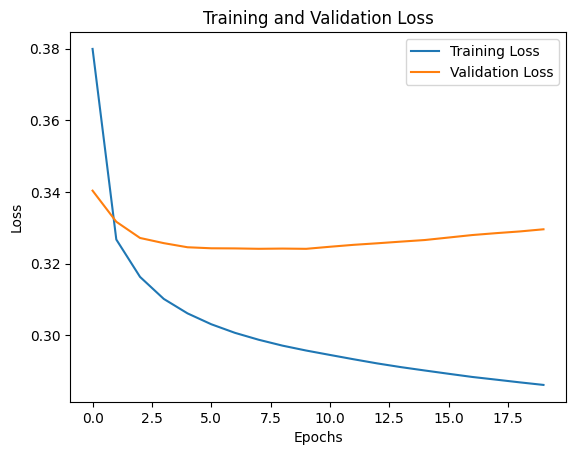

In [21]:
# plot loss vs val_loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

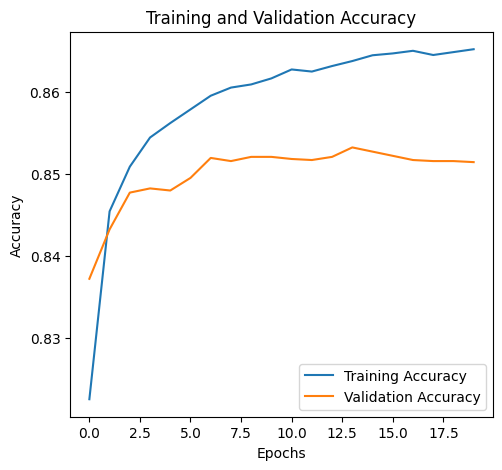

In [22]:
# plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

Experimenting

In [23]:
# Experiment 1: What happens when I build a larger neural network

tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train_scaled.shape[1],))

x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_exp1 = keras.Model(inputs=inputs, outputs=outputs, name="adult_income_exp1_larger")

model_exp1.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_exp1 = model_exp1.fit(
    X_train_scaled,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

scores_exp1 = model_exp1.evaluate(X_test_scaled, y_test, verbose=1)

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8163 - loss: 0.3871 - val_accuracy: 0.8425 - val_loss: 0.3368
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8481 - loss: 0.3231 - val_accuracy: 0.8484 - val_loss: 0.3294
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.3126 - val_accuracy: 0.8499 - val_loss: 0.3266
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8575 - loss: 0.3063 - val_accuracy: 0.8498 - val_loss: 0.3253
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8596 - loss: 0.3021 - val_accuracy: 0.8505 - val_loss: 0.3252
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8613 - loss: 0.2988 - val_accuracy: 0.8499 - val_loss: 0.3251
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8622 - loss: 0.2960 - val_accuracy: 0.8500 - val_loss: 0.3250
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8635 - loss: 0.2937 - val_accuracy: 0.

In [24]:
# Experiment 2: What happens if I use a larger model with dropout

tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train_scaled.shape[1],))

x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_exp2 = keras.Model(inputs=inputs, outputs=outputs, name="adult_income_exp2_dropout")

model_exp2.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_exp2 = model_exp2.fit(
    X_train_scaled,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

scores_exp2 = model_exp2.evaluate(X_test_scaled, y_test, verbose=1)

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8001 - loss: 0.4259 - val_accuracy: 0.8386 - val_loss: 0.3422
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8374 - loss: 0.3535 - val_accuracy: 0.8425 - val_loss: 0.3336
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8406 - loss: 0.3443 - val_accuracy: 0.8477 - val_loss: 0.3288
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8446 - loss: 0.3325 - val_accuracy: 0.8472 - val_loss: 0.3251
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8488 - loss: 0.3265 - val_accuracy: 0.8499 - val_loss: 0.3230
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.3222 - val_accuracy: 0.8463 - val_loss: 0.3222
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3175 - val_accuracy: 0.8479 - val_loss: 0.3221
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.3147 - val_accuracy: 0.

In [25]:
# Experiment 3: What happens when I use a larger model with dropout and smaller batch size

tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train_scaled.shape[1],))

x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_exp3 = keras.Model(inputs=inputs, outputs=outputs, name="adult_income_exp3_dropout_batch32")

model_exp3.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_exp3 = model_exp3.fit(
    X_train_scaled,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

scores_exp3 = model_exp3.evaluate(X_test_scaled, y_test, verbose=1)

Epoch 1/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8165 - loss: 0.3992 - val_accuracy: 0.8436 - val_loss: 0.3329
Epoch 2/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8438 - loss: 0.3413 - val_accuracy: 0.8467 - val_loss: 0.3282
Epoch 3/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8478 - loss: 0.3270 - val_accuracy: 0.8464 - val_loss: 0.3249
Epoch 4/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8507 - loss: 0.3227 - val_accuracy: 0.8476 - val_loss: 0.3238
Epoch 5/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8530 - loss: 0.3195 - val_accuracy: 0.8488 - val_loss: 0.3239
Epoch 6/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8539 - loss: 0.3149 - val_accuracy: 0.8475 - val_loss: 0.3241
Epoch 7/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8566 - loss: 0.3128 - val_accuracy: 0.8493 - val_loss: 0.3224
Epoch 8/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8548 - loss: 0.3109 - val_accuracy: 0.

In [26]:
#evaluating all models
# function to evaluate each model

def evaluate_model(model, X_test_scaled, y_test, model_name):
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [27]:
# compare baseline and experiment models

results = []

results.append(evaluate_model(model, X_test_scaled, y_test, "Baseline"))
results.append(evaluate_model(model_exp1, X_test_scaled, y_test, "Experiment 1: Larger Model"))
results.append(evaluate_model(model_exp2, X_test_scaled, y_test, "Experiment 2: Dropout"))
results.append(evaluate_model(model_exp3, X_test_scaled, y_test, "Experiment 3: Dropout + Batch 32"))

results_df = pd.DataFrame(results)
results_df

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.852493,0.726401,0.615483,0.666358,0.906494
1,Experiment 1: Larger Model,0.853311,0.741333,0.594525,0.659862,0.903574
2,Experiment 2: Dropout,0.854847,0.769953,0.561163,0.649184,0.911621
3,Experiment 3: Dropout + Batch 32,0.856075,0.772834,0.564585,0.652496,0.911567


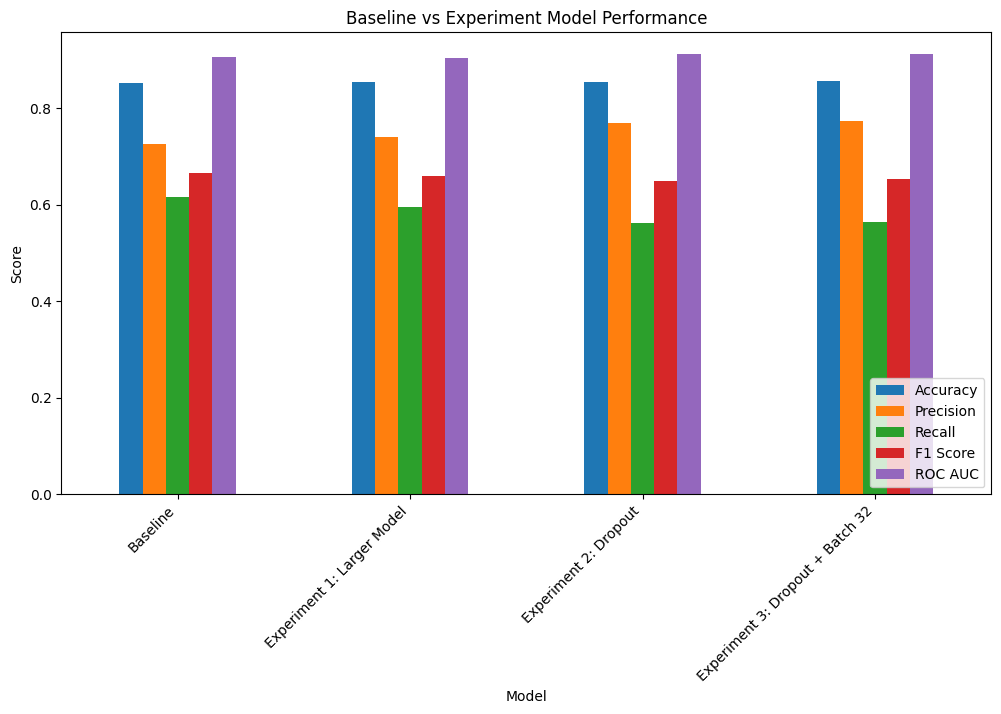

In [28]:
# plot model comparison

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline vs Experiment Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.show()

### Using Optuna to tune

In [29]:
# install optuna if needed
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.1 MB/s eta 0:00:00


In [30]:
import optuna

# tuning the neural network with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 4)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)

    inputs = keras.Input(shape=(X_train_scaled.shape[1],))
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 16, 128)
        x = layers.Dense(units, activation="relu")(x)

        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,
        validation_split=0.2,
        verbose=0,
        callbacks=[early_stop]
    )

    return min(history.history["val_loss"])

In [31]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-21 00:08:13,055] A new study created in memory with name: no-name-72d57330-297b-462f-9d9d-657bdec7a4d9
[I 2026-05-21 00:08:42,197] Trial 0 finished with value: 0.3236886262893677 and parameters: {'num_layers': 4, 'learning_rate': 0.00020074887590858606, 'batch_size': 32, 'dropout_rate': 0.18312921711024938, 'num_units_layer_1': 70, 'num_units_layer_2': 89, 'num_units_layer_3': 67, 'num_units_layer_4': 111}. Best is trial 0 with value: 0.3236886262893677.
[I 2026-05-21 00:08:59,899] Trial 1 finished with value: 0.3213936686515808 and parameters: {'num_layers': 1, 'learning_rate': 0.0007513516036558266, 'batch_size': 32, 'dropout_rate': 0.4855758546254701, 'num_units_layer_1': 87}. Best is trial 1 with value: 0.3213936686515808.
[I 2026-05-21 00:09:22,641] Trial 2 finished with value: 0.33505135774612427 and parameters: {'num_layers': 4, 'learning_rate': 0.0028803381345202618, 'batch_size': 32, 'dropout_rate': 0.4564225143838212, 'num_units_layer_1': 114, 'num_units_layer_2': 

Best validation loss: 0.3205235004425049
Best parameters: {'num_layers': 1, 'learning_rate': 0.000636369167898184, 'batch_size': 64, 'dropout_rate': 0.43222724686199654, 'num_units_layer_1': 105}


In [32]:
optuna.visualization.plot_optimization_history(study)

In [33]:
optuna.visualization.plot_param_importances(study)

In [34]:
optuna.visualization.plot_slice(study)

In [35]:
# Building the best model from Optuna results

best_params = study.best_params

num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout_rate = best_params["dropout_rate"]

inputs = keras.Input(shape=(X_train_scaled.shape[1],))
x = inputs

for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

best_model = keras.Model(inputs=inputs, outputs=outputs, name="best_adult_income_model")

best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"]
)

best_model.summary()

Model: "best_adult_income_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 105)            │        10,605 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 105)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │           106 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,711 (41.84 KB)

 Trainable params: 10,711 (41.84 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_best = best_model.fit(
    X_train_scaled,
    y_train,
    batch_size=batch_size,
    epochs=50,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

scores_best = best_model.evaluate(X_test_scaled, y_test, verbose=1)

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8069 - loss: 0.4184 - val_accuracy: 0.8385 - val_loss: 0.3382
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8385 - loss: 0.3498 - val_accuracy: 0.8450 - val_loss: 0.3290
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8444 - loss: 0.3367 - val_accuracy: 0.8499 - val_loss: 0.3243
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8491 - loss: 0.3260 - val_accuracy: 0.8498 - val_loss: 0.3232
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8524 - loss: 0.3199 - val_accuracy: 0.8526 - val_loss: 0.3220
Epoch 6/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8512 - loss: 0.3161 - val_accuracy: 0.8516 - val_loss: 0.3219
Epoch 7/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.3146 - val_accuracy: 0.8518 - val_loss: 0.3218
Epoch 8/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8551 - loss: 0.3115 - val_accuracy: 0.

In [37]:
# evaluate the best model using the test set

y_pred_prob = best_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\nBest Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Best Model Test Set Evaluation:
Test Accuracy: 0.8591
Test Precision: 0.7529
Test Recall: 0.6125
Test F1 Score: 0.6755
Test ROC AUC Score: 0.9103


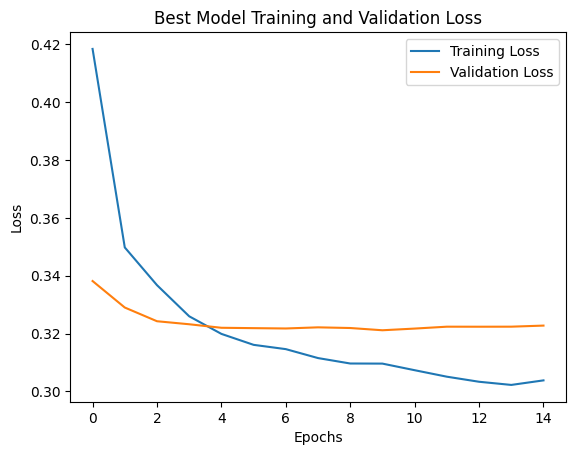

In [38]:
# plot loss vs val_loss for best model

plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Best Model Training and Validation Loss')
plt.legend()
plt.show()

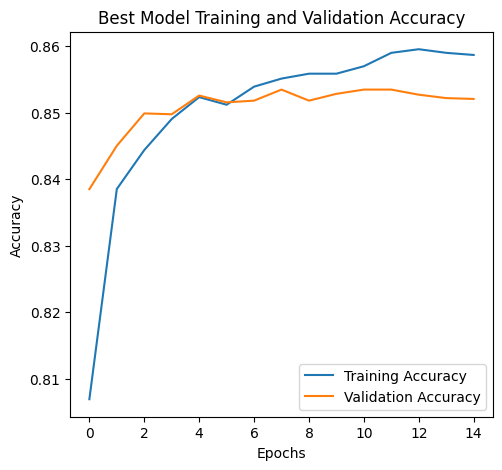

In [39]:
# plot training and validation accuracy for best model

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Best Model Training and Validation Accuracy')
plt.legend()

plt.show()

In [40]:
best_results = evaluate_model(best_model, X_test_scaled, y_test, "Best Optuna Model")

results.append(best_results)

final_results_df = pd.DataFrame(results)
final_results_df

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.852493,0.726401,0.615483,0.666358,0.906494
1,Experiment 1: Larger Model,0.853311,0.741333,0.594525,0.659862,0.903574
2,Experiment 2: Dropout,0.854847,0.769953,0.561163,0.649184,0.911621
3,Experiment 3: Dropout + Batch 32,0.856075,0.772834,0.564585,0.652496,0.911567
4,Best Optuna Model,0.859146,0.752892,0.612489,0.675472,0.910289


The best overall model was the Optuna-tuned neural network. It achieved the highest test accuracy at 0.8591 and the highest F1 score at 0.6755. This suggests that systematic tuning improved the balance between precision and recall compared to the baseline and manual experiments.

The baseline model already performed well with an accuracy of 0.8525 and ROC AUC of 0.9065. The larger model did not improve much, which suggests that simply increasing model size was not enough. Adding dropout improved precision and ROC AUC, but recall decreased, meaning the model became more conservative when predicting income above 50K.

The best Optuna model provided the strongest overall performance. Although Experiment 2 had the highest ROC AUC, the Optuna model had the best accuracy and F1 score, making it the strongest final choice for this classification task.

### Personal Workflow for Building Neural Networks

In the future, I would start by understanding the problem and deciding whether a neural network is appropriate. Then I would clean and prepare the data by handling missing values, encoding categorical variables, splitting the data properly, and scaling numeric features.

Next, I would build a simple baseline model before making the architecture more complex. I would use training and validation curves to check whether the model is underfitting or overfitting. After that, I would run experiments where I change one factor at a time, such as layer size, dropout, batch size, or learning rate.

Once I understand which changes help, I would use a systematic tuning method such as Optuna to search for better hyperparameters. Finally, I would evaluate the best model on a held-out test set using accuracy, precision, recall, F1 score, ROC AUC, and training behavior.

The main best practices I would follow are avoiding data leakage, keeping the test set separate until final evaluation, using early stopping, comparing models fairly, and not assuming that a larger model is automatically better.

Summary of Personal Workflow (from class, but notes for me)

understand the problem, prepare the data, simple baseline model, train/validation curves, adjust capacity (early stopping), fair comparisons, tune systematically, and evaluate final model performance and stability